# M2 · HITL damage identification and segmentation

Manual experiments for nine semantic labels: eight HITL damage categories plus background. The default `focused_640` recipe combines ADE20K-pretrained SegFormer-B2, adaptive decoder BatchNorm, detail-preserving training crops and validation-plateau learning-rate reduction. Each setting is editable. Controlled presets isolate changes; no gain is assumed until validation is measured.

The completed v2 reference run reached **0.2224 validation foreground mIoU** at epoch 9, then stopped at epoch 24. Its checkpoints remain under `artifacts/models/damage-hitl/damage-segformer-20261001T003540Z-6203ed59`. Existing outputs were backed up under `artifacts/exports/notebook-backups/` before this notebook was updated. Cleared cells below do not represent a completed improved run.

HITL damage is a distinct taxonomy from CarDD. Segmentation scores do not establish damage-to-part assignment, side, severity or repair necessity. Full training and final-test evaluation remain manual.


## Training plan and workflow

1. Reuse the immutable v2 HITL labels and shared M1/M2 split; no relabelling or split changes are introduced here.
2. Audit flaking, paint-chip and scratch examples against the original polygons. Review the sampled transformed crops before fitting.
3. Choose a preset below. `previous` reproduces the completed M2 configuration; `bn_only`, `ade`, `plateau`, `focused_512`, `focused_640` and `rare_sampling` form a sequence of controlled comparisons. The default `focused_640` combines several changes and must be reported as a recipe comparison.
4. Select checkpoints by validation foreground mIoU, retaining per-class support and binary damage metrics. Plateau reductions get time to take effect before early stopping.
5. Compare resolutions by explicitly rescoring every candidate at the same evaluation size. Keep those reports separate from original run metrics.
6. Try UperNet–ConvNeXt only as a separate architecture experiment; repeat finalists with 2–3 training seeds while keeping the data split fixed. Open the final test only after freezing the protocol.

Full-resolution tiled inference and exact optimizer resume remain future work. These notebook changes neither start a training job nor promote a model to the application.


## Environment and repository paths

Use a dedicated Python environment and select it as the Jupyter kernel. `requirements-training.txt` defines the training dependencies. On an NVIDIA machine, install the appropriate PyTorch/CUDA build for that machine first. On Apple Silicon, the native macOS PyTorch build can use Metal (`mps`). The optional installation cell is disabled by default and runs in the current kernel's Python only when explicitly enabled. Restart the kernel after installation, then rerun from the first cell.


In [1]:
from pathlib import Path
import sys
import json
import os

# Works when Jupyter starts in the repository root or a subdirectory such as notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "docs/specs/README.md").is_file()
             and (p / "pipelines").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start Jupyter inside the CLAIM-CMEV checkout, or set ROOT to its path.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
# Set caches before importing transformers/torch; preserve any user overrides.
os.environ.setdefault("HF_HOME", str(ROOT / "artifacts/models/.cache/huggingface"))
os.environ.setdefault("TORCH_HOME", str(ROOT / "artifacts/models/.cache/torch"))
print("Repository:", ROOT)
print("Kernel Python:", sys.executable)


Repository: /Users/rodel/Projects/nus/CLAIM-CMEV
Kernel Python: /Users/rodel/Projects/nus/CLAIM-CMEV/venv/bin/python


In [2]:
INSTALL_DEPENDENCIES = False  # Set True only to install into this kernel's environment.
if INSTALL_DEPENDENCIES:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r",
                           str(ROOT / "requirements-training.txt")])
    print("Restart the kernel after installation, then rerun this notebook.")


In [3]:
from dataclasses import asdict
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from IPython.display import display

from pipelines.vision.hitl_data import prepare_hitl
from pipelines.vision.training import (
    TrainingConfig, train, evaluate_run, select_device, build_model, model_summary,
    plot_history, plot_confusion, show_predictions, show_targets, compare_runs,
)

DEVICE = "auto"  # auto -> CUDA, then Apple MPS, then CPU; or "cuda", "mps", "cpu".
print("PyTorch:", torch.__version__)
print("Selected device:", select_device(DEVICE))
print("CUDA available:", torch.cuda.is_available())
print("Apple MPS available:", torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

from pipelines.vision.training import SegmentationDataset, repeat_sampling_weights


PyTorch: 2.14.0
Selected device: mps
CUDA available: False
Apple MPS available: True


## Shared HITL preprocessing and leakage controls

The converter reads Supervisely `meta.json` and asserts the exact task vocabulary rather than trusting directory names. It rasterizes polygon exteriors and interior holes at source resolution. HITL annotators nest polygons: a door includes its window and mirror, a bumper its licence plate and grille, a dent its scratches. Same-class overlap is merged. When two polygons of different classes overlap and at least 80% of the smaller one lies inside the larger, the smaller polygon keeps the shared pixels. Other different-class overlaps, such as slivers at part seams or partially overlapping damage, are marked ignore ID 255. This `nested` policy follows the training specification's smaller-region-on-top proposal and is recorded in the manifest.

The first preparation, `data/processed/hitl/v1`, ignored every different-class overlap. It discarded most window, mirror and licence-plate labels (63-88% of their annotated pixels), so v1 and v2 results are not comparable. v1 remains available with `OVERLAP_POLICY = "ignore_all"`. Background is ID 0; padding and ignored overlap are ID 255 and are ignored by the loss and metrics. **Do not reduce the class IDs** as for some ADE20K examples: HITL background is a real training class.

Images and masks are orientation aligned during conversion; ambiguous EXIF/annotation frames fail for manual review rather than silently guessing alignment. Training preserves aspect ratio, resizes images with bilinear interpolation and masks with nearest-neighbor interpolation, and pads centrally to the configured square size. Padding uses the normalization mean in RGB and ignore ID 255 in labels. The conversion manifest retains original dimensions and orientation; the recorded image size and centered-letterbox policy reproduce the model-frame geometry. Metrics are measured on this resized/padded grid with ignored pixels excluded, not on native-resolution masks. ImageNet mean/std are explicit configuration below; change them together when a different checkpoint requires different normalization.

Only training examples are augmented. `damage_aware` chooses 25% full photographs, 50% focused crops and 25% ordinary random crops by default. Focused crops choose a preferred foreground class present in that photograph, then a pixel of that class; the crop includes that pixel. Crop side length is `image_size / sampled_zoom` in original normalized image pixels, with zoom 1.0–1.5, so these crops do not shrink the image first. Small images are padded with ignore 255. Full-image examples preserve context, while random examples retain background/negative supervision. The default focused recipe disables rotation so its tiny target anchor is not rotated out of view.

Validation and inference always use the whole photograph with deterministic aspect-preserving resize/padding. They never use ground-truth crop locations. Optional repeat-factor sampling uses training-image class prevalence only, caps the weight, and keeps the number of samples per epoch fixed. It is separate from the default recipe. No heavy blur is applied. Background means unannotated, not confidently undamaged.

Both notebooks must use the same `PREPARED_DIR`, split seed, ratios, optional group CSV and optional reservation file. Byte hashes and decoded-pixel hashes link duplicate photographs across both subsets. If vehicle/source identity is known, supply a CSV with `sample_id` or `content_sha256`, plus `group_id`; this adds grouping beyond exact image duplicates. `RESERVED_IDS` can identify samples/content hashes to exclude from segmentation training, validation and test for a separate assignment study.

Review the conversion and near-duplicate audit before training. Numerical comparison with publisher `masks_machine` is not yet performed because its palette semantics have not been established; the manifest records this limitation, and the overlays below require visual inspection. Exact hashes alone do not establish vehicle independence; unresolved near duplicates or missing vehicle IDs remain stated limitations. Adjust groups before freezing the manifest and use a new prepared-data version if the split policy or source changes. Never move test examples after seeing their model errors.


In [4]:
# Keep these settings IDENTICAL in M1 and M2.
RAW_ROOT = ROOT / "data/raw"
PREPARED_DIR = ROOT / "data/processed/hitl/v2"  # v1 = first preparation, ignore_all overlap
SPLIT_SEED = 20260922
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
OVERLAP_POLICY = "nested"  # "ignore_all" reproduces v1
NESTED_CONTAINMENT = 0.8  # share of the smaller polygon inside the larger one
GROUP_CSV = None  # e.g. ROOT / "data/manifests/hitl_vehicle_groups.csv"
RESERVED_IDS = None  # e.g. ROOT / "data/manifests/assignment_reservations.json"

# Both parts AND damage subsets must be present. Missing inputs fail clearly.
# Source content is inspected; do not rename folders just to infer the task.
manifest = prepare_hitl(
    raw_root=RAW_ROOT,
    output_dir=PREPARED_DIR,
    seed=SPLIT_SEED,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
    group_csv=GROUP_CSV,
    reserved_ids=RESERVED_IDS,
    overlap_policy=OVERLAP_POLICY,
    nested_containment=NESTED_CONTAINMENT,
)
print("Prepared data:", PREPARED_DIR)
print("Shared manifest hash:", manifest["manifest_hash"])
print("Review converter reports and grouping limitations in:", PREPARED_DIR)
display(manifest.get("near_duplicate_audit", {}))
display(manifest.get("split", {}))


Prepared data: /Users/rodel/Projects/nus/CLAIM-CMEV/data/processed/hitl/v2
Shared manifest hash: d28a613cc29735304987f1bc4c806585856a09af0666bb736613f1f1a91beed8
Review converter reports and grouping limitations in: /Users/rodel/Projects/nus/CLAIM-CMEV/data/processed/hitl/v2


{'method': '64-bit grayscale dHash, Hamming distance <= 4',
 'candidate_count': 0,
 'cross_split_candidates': 0,
 'status': 'no_candidates_at_selected_threshold',
 'sha256': '37517e5f3dc66819f61f5a7bb8ace1921282415f10551d2defa5c3eb0985b570',
 'path': 'near_duplicate_candidates.json',
 'limits': 'Candidates can be false positives; absence does not exclude related views.'}

{'group_counts': {'train': 959, 'val': 206, 'test': 206},
 'grouping_policy': 'union of file SHA256, decoded RGB SHA256 and supplied group CSV',
 'provided_group_rows': 0,
 'reserved_identifiers': 0,
 'vehicle_independence_established': False,
 'limitations': 'Exact/pixel duplicates are grouped. Vehicle/related-view identity is unknown unless supplied and reviewed.'}

Class IDs: {0: 'background', 1: 'dent', 2: 'cracked', 3: 'scratch', 4: 'flaking', 5: 'broken-part', 6: 'paint-chip', 7: 'missing-part', 8: 'corrosion'}


,partition,images
0,test,124
1,train,558
2,val,132


,class,training_pixels
0,background,174223528
1,dent,3694343
2,cracked,912280
3,scratch,1065133
4,flaking,280240
5,broken-part,8382820
6,paint-chip,207126
7,missing-part,1545209
8,corrosion,148611


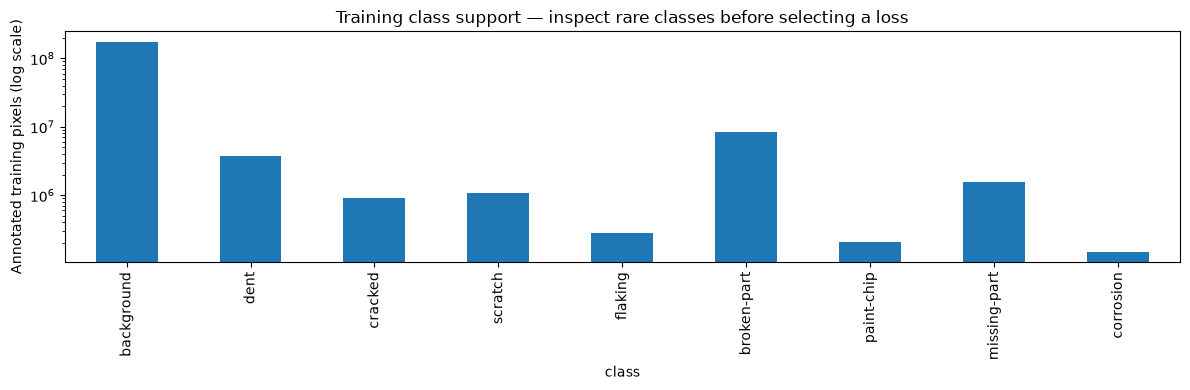

In [5]:
TASK = 'damage'
class_names = manifest["class_names"][TASK]
records = [r for r in manifest["records"] if r["task"] == TASK]
assert len(class_names) == 9, f"Unexpected taxonomy: {class_names}"
assert class_names[0] == "background"
print("Class IDs:", dict(enumerate(class_names)))
display(pd.DataFrame(sorted(Counter(r["split"] for r in records).items()),
                     columns=["partition", "images"]))

# Show training pixel support only; validation and final reports report their own support.
train_records = [r for r in records if r["split"] == "train"]
assert train_records, "No training samples: inspect conversion/split reports."
pixel_counts = np.zeros(len(class_names), dtype=np.int64)
for record in train_records:
    with Image.open(record["mask_path"]) as im:
        labels = np.asarray(im)
        pixel_counts += np.bincount(labels[labels < len(class_names)].ravel(),
                                    minlength=len(class_names))
support = pd.DataFrame({"class": class_names, "training_pixels": pixel_counts})
display(support)
ax = support.set_index("class")["training_pixels"].plot.bar(figsize=(12, 4), logy=True)
ax.set_ylabel("Annotated training pixels (log scale)")
ax.set_title("Training class support — inspect rare classes before selecting a loss")
plt.tight_layout()


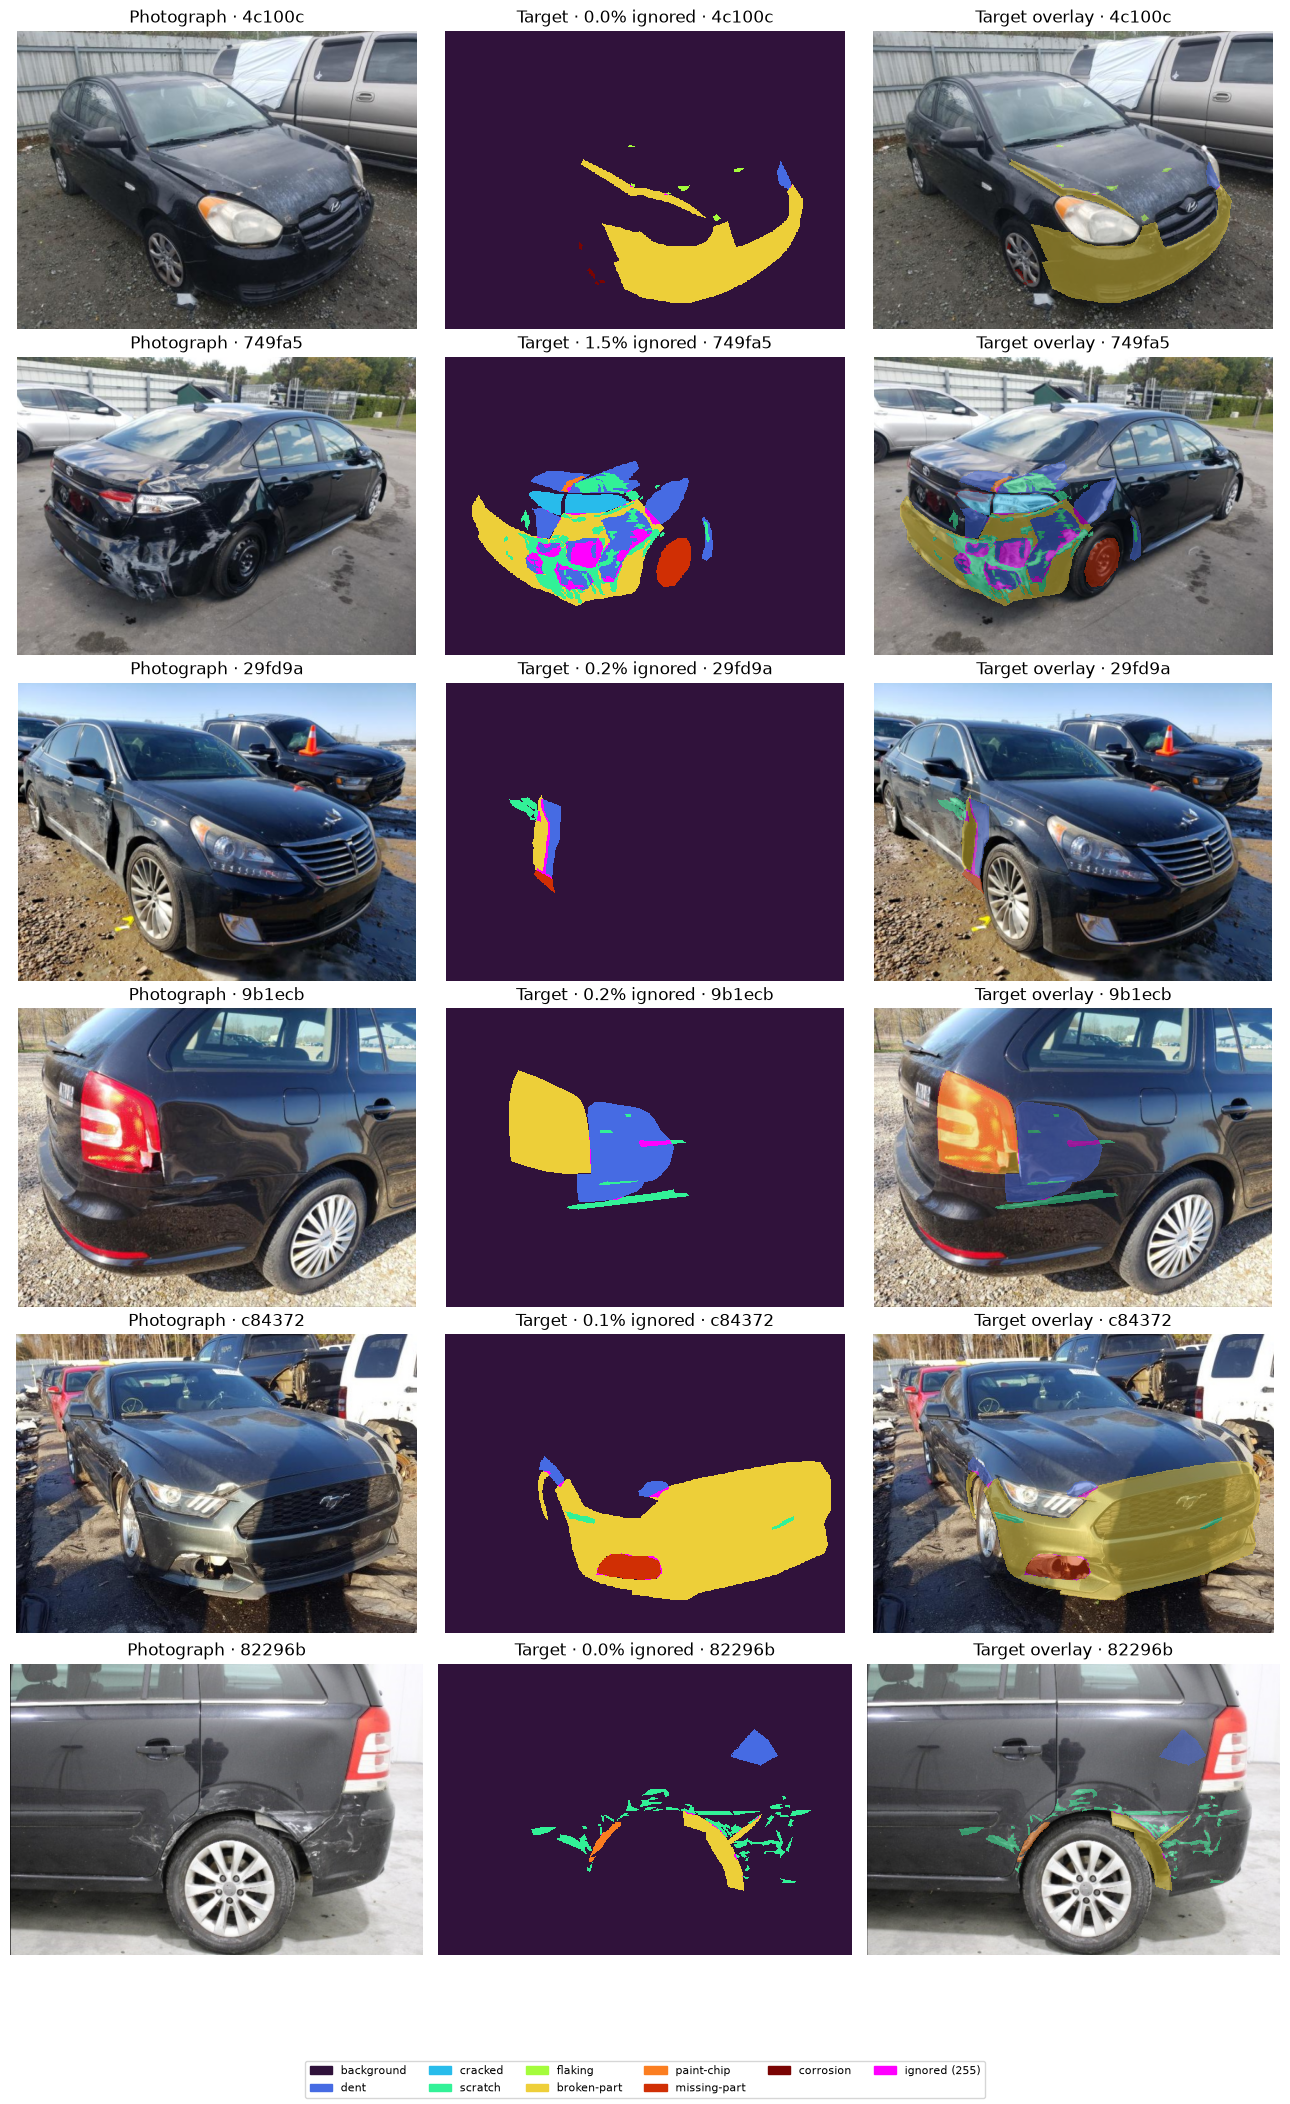

,class,sample_id,source_image,source_polygon_json
0,flaking,damage-05593416172792025aa7f74c,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
1,flaking,damage-0eec9f7db050891ec49a4e12,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
2,flaking,damage-1258e2efe1d5f3a5025224a2,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
3,paint-chip,damage-009a77aa9d98ddd8fdc49b8e,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
4,paint-chip,damage-0326e5c9e84c867b190a4b25,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
5,paint-chip,damage-033c3ed02c64e8b780092a94,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
6,scratch,damage-009a77aa9d98ddd8fdc49b8e,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
7,scratch,damage-033c3ed02c64e8b780092a94,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...
8,scratch,damage-048e431a998cb77f1ab6638f,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...


In [6]:
# Inspect prepared labels against original evidence, using TRAIN examples only.
AUDIT_CLASSES = ["flaking", "paint-chip", "scratch"]
show_targets(manifest, TASK, split="train", count=6, seed=0, focus_classes=AUDIT_CLASSES)
plt.show()
# Original annotation locators for a bounded review; never repair labels from predictions.
audit_rows = []
for name in AUDIT_CLASSES:
    idx = class_names.index(name)
    examples = [r for r in train_records if r["pixel_counts"][idx] > 0][:3]
    for r in examples:
        audit_rows.append({"class": name, "sample_id": r["sample_id"],
                           "source_image": str(RAW_ROOT / r["source_image"]),
                           "source_polygon_json": str(RAW_ROOT / r["source_annotation"])})
display(pd.DataFrame(audit_rows))
# Any reviewed label correction requires a new prepared version and a recorded reason.


## Encoder, decoder and experiment controls

`nvidia/segformer-b2-finetuned-ade-512-512` supplies a pretrained MiT-B2 encoder **and** ADE20K-trained segmentation decoder. The existing all-MLP multiscale projections/fusion transfer; the final 1×1 classifier is reinitialized for our **nine classes**. Its lower-resolution logits are bilinearly upsampled before loss and pixel metrics. Background remains ID 0; labels are not reduced. `nvidia/mit-b2`, used by `previous` and `bn_only`, instead initializes the full segmentation decoder from scratch.

SegFormer presets now adapt the decoder BatchNorm running statistics (`freeze_batchnorm=False`). This is distinct from freezing encoder parameters; gradient accumulation does not increase BatchNorm's physical batch size. ResNet/DeepLab and the optional UperNet preset retain frozen BatchNorm for small-batch pooling stability.

The `plateau` schedule uses linear warmup per optimizer update, then monitors validation foreground mIoU each epoch. It halves learning rates after `plateau_patience + 1` non-improving observations, down to the configured floor. Early stopping waits `plateau_grace_epochs` complete epochs after an actual rate reduction. This avoids ending the run before a lower-rate phase has been tested. Exact stateful resume is not implemented.

| Preset | Change relative to preceding preset |
| --- | --- |
| `previous` | Completed v2 M2 reference: MiT-B2, frozen BN, scale 0.5–2, 512, poly schedule |
| `bn_only` | Train SegFormer decoder BatchNorm statistics |
| `ade` | Transfer ADE20K encoder and decoder |
| `plateau` | Warmup followed by validation-triggered rate reductions |
| `focused_512` | Full/random/focused crop mixture; no aggressive shrinking or rotation |
| `focused_640` | Same recipe at 640 pixels; **default combined candidate** |
| `rare_sampling` | Add capped training-image repeat-factor sampling |
| `convnext` | Compare UperNet–ConvNeXt-small at 640; different architecture and BN policy |

UperNet is available through `architecture="hf_semantic"`; this harness uses its main dense logits and custom CE + Dice loss, **not its standard auxiliary loss**. Its accuracy and Mac GPU memory requirements need separate validation. For ResNet alternatives use `architecture="resnet50"`/`"resnet101"` and `freeze_batchnorm=True`. Larger models do not guarantee better small-damage performance.

Reference: [ADE20K SegFormer-B2 checkpoint](https://huggingface.co/nvidia/segformer-b2-finetuned-ade-512-512).


In [7]:
# Change one factor at a time for attribution, or report the default as a combined recipe.
RECIPE = "focused_640"
BASE_RECIPE = dict(
    architecture="segformer", checkpoint="nvidia/mit-b2", image_size=512,
    encoder_lr=6e-5, head_lr=6e-4, lr_schedule="poly", warmup_epochs=2,
    epochs=100, patience=15, freeze_batchnorm=True,
    scale_range=(0.5, 2.0), rotation_degrees=10, saturation=0.15,
)
RECIPES = {"previous": BASE_RECIPE}
RECIPES["bn_only"] = {**BASE_RECIPE, "freeze_batchnorm": False}
RECIPES["ade"] = {**RECIPES["bn_only"],
    "checkpoint": "nvidia/segformer-b2-finetuned-ade-512-512"}
RECIPES["plateau"] = {**RECIPES["ade"], "lr_schedule": "plateau"}
RECIPES["focused_512"] = {**RECIPES["plateau"], "crop_mode": "damage_aware",
    "scale_range": (1.0, 1.0), "rotation_degrees": 0, "saturation": 0.10,
    "full_image_probability": 0.25, "focused_crop_probability": 0.50,
    "crop_scale_range": (1.0, 1.5),
    "crop_focus_class_ids": tuple(class_names.index(name) for name in
                                  ["flaking", "paint-chip", "scratch", "cracked"])}
RECIPES["focused_640"] = {**RECIPES["focused_512"], "image_size": 640}
RECIPES["rare_sampling"] = {**RECIPES["focused_640"],
    "repeat_factor_threshold": 0.20, "max_repeat_factor": 3.0}
RECIPES["convnext"] = {**RECIPES["focused_640"], "architecture": "hf_semantic",
    "checkpoint": "openmmlab/upernet-convnext-small", "freeze_batchnorm": True}

# Override any preset here; keep this visible when reporting a run.
OVERRIDES = {}  # e.g. {"image_size": 512, "batch_size": 1, "accumulation_steps": 8}
TRAINING_SEED = 20260922  # Change for repeated fits; SPLIT_SEED stays fixed.
settings = dict(task=TASK, revision=None, pretrained=True, batch_size=2,
    accumulation_steps=4, weight_decay=0.01, freeze_encoder_epochs=0,
    ce_weight=1.0, dice_weight=0.5, horizontal_flip=0.5,
    brightness=0.15, contrast=0.15, plateau_patience=3, plateau_factor=0.5,
    plateau_min_lr_ratio=0.01, plateau_grace_epochs=3,
    mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225),
    device=DEVICE, amp=True, workers=0, seed=TRAINING_SEED,
    artifacts_root=str(ROOT / "artifacts"), run_id=None)
settings.update(RECIPES[RECIPE])
settings.update(OVERRIDES)
cfg = TrainingConfig(**settings)
print("Recipe:", RECIPE)
print(json.dumps(asdict(cfg), indent=2))
print("640 versus 512 uses 1.56x as many input pixels; reduce batch size if needed.")
print("Artifacts:", ROOT / "artifacts/models/damage-hitl")


Recipe: focused_640
{
  "task": "damage",
  "architecture": "segformer",
  "checkpoint": "nvidia/segformer-b2-finetuned-ade-512-512",
  "revision": null,
  "pretrained": true,
  "image_size": 640,
  "batch_size": 2,
  "epochs": 100,
  "encoder_lr": 6e-05,
  "head_lr": 0.0006,
  "weight_decay": 0.01,
  "patience": 15,
  "min_delta": 0.0,
  "freeze_encoder_epochs": 0,
  "freeze_batchnorm": false,
  "accumulation_steps": 4,
  "ce_weight": 1.0,
  "dice_weight": 0.5,
  "max_grad_norm": 1.0,
  "lr_schedule": "plateau",
  "warmup_epochs": 2,
  "poly_power": 1.0,
  "horizontal_flip": 0.5,
  "brightness": 0.15,
  "contrast": 0.15,
  "saturation": 0.1,
  "scale_range": [
    1.0,
    1.0
  ],
  "rotation_degrees": 0,
  "crop_mode": "damage_aware",
  "full_image_probability": 0.25,
  "focused_crop_probability": 0.5,
  "crop_scale_range": [
    1.0,
    1.5
  ],
  "crop_focus_class_ids": [
    4,
    6,
    3,
    2
  ],
  "repeat_factor_threshold": 0.0,
  "max_repeat_factor": 3.0,
  "plateau_pati

## Preview the actual training crops

These are labels and transformed training examples, not model predictions. Check that chips, flakes and scratches remain visible at the selected scale. The crop mix retains full context and random background; sampling weights are computed only from the training split. Preferred target classes are chosen within images that contain them. A mask-driven crop is never used to choose a validation/test window.


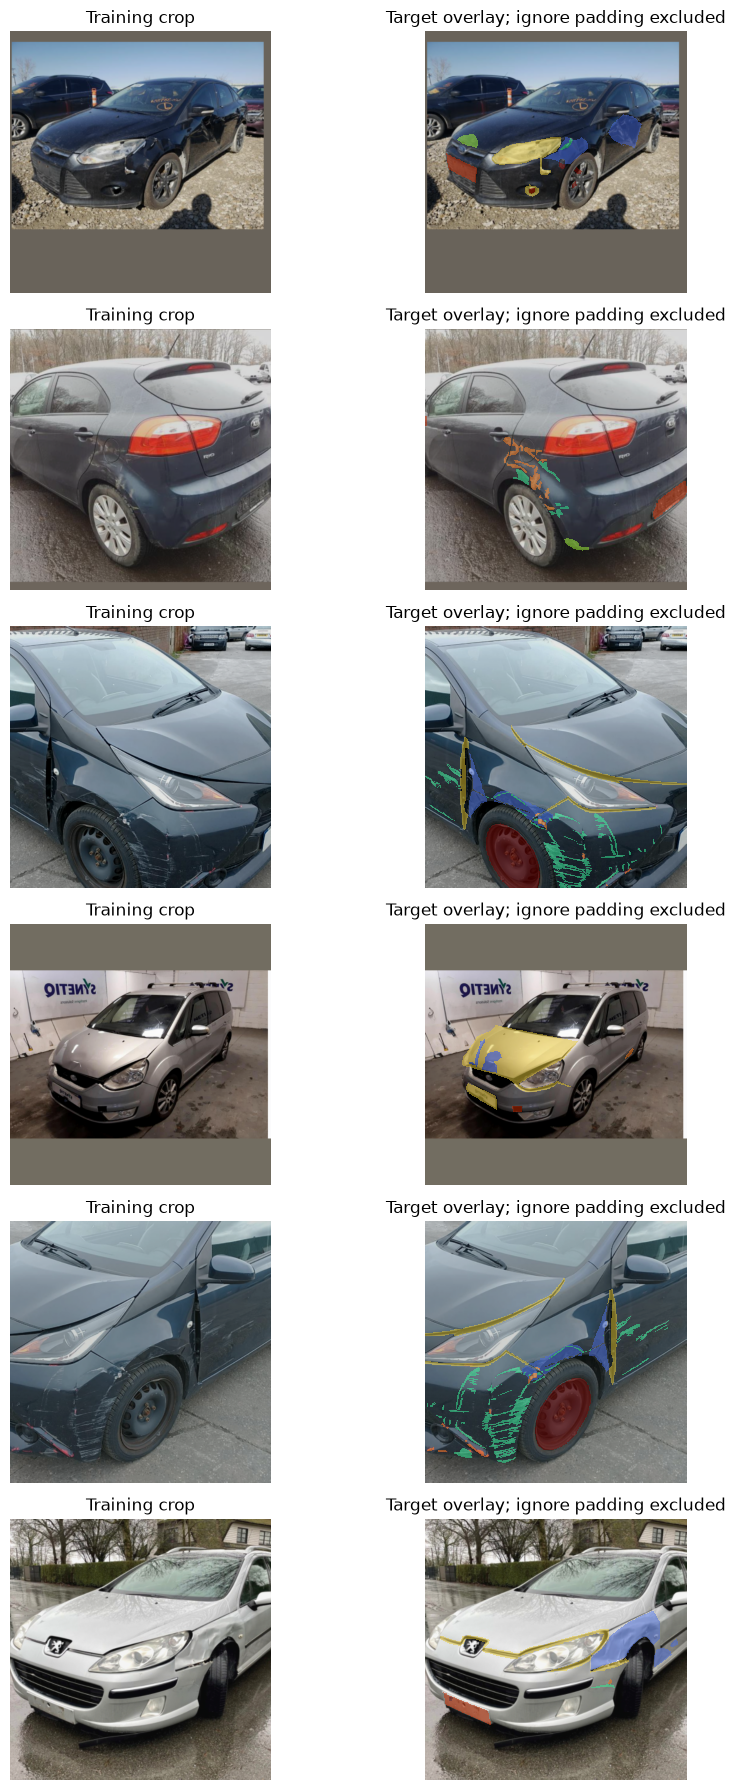

Sampling weights min/max: 1.0 1.0 (all 1 means uniform; validation never uses this sampler)


In [8]:
import random
# Select examples with the classes that performed poorly, plus ordinary context.
preview_records = []
for name in AUDIT_CLASSES:
    candidates = [r for r in train_records if r["pixel_counts"][class_names.index(name)] > 0]
    preview_records.extend(candidates[:2])
preview_dataset = SegmentationDataset(preview_records, cfg, training=True, num_classes=len(class_names))
state = random.getstate()
random.seed(7)
fig, axes = plt.subplots(len(preview_records), 2, figsize=(10, 3 * len(preview_records)), squeeze=False)
try:
    for row in range(len(preview_records)):
        item = preview_dataset[row]
        rgb = item["pixel_values"].numpy().transpose(1, 2, 0) * np.asarray(cfg.std) + np.asarray(cfg.mean)
        labels = item["labels"].numpy()
        for axis in axes[row]:
            axis.imshow(rgb.clip(0, 1)); axis.axis("off")
        axes[row, 1].imshow(np.ma.masked_where((labels == 0) | (labels == 255), labels),
            cmap="turbo", vmin=0, vmax=len(class_names)-1, alpha=0.5, interpolation="nearest")
        axes[row, 0].set_title("Training crop")
        axes[row, 1].set_title("Target overlay; ignore padding excluded")
finally:
    random.setstate(state)
plt.tight_layout(); plt.show()
weights = repeat_sampling_weights(train_records, len(class_names),
    cfg.repeat_factor_threshold, cfg.max_repeat_factor)
print("Sampling weights min/max:", min(weights), max(weights),
      "(all 1 means uniform; validation never uses this sampler)")


## Inspect the model architecture

The next cell builds the configured model once, on the CPU, so you can see it before training. The table lists modules down to `SUMMARY_DEPTH` levels with their parameter counts, and marks whether it belongs to the pretrained encoder or the newly initialised decoder/head. A test pass with a blank image confirms the model returns one score per class for every input pixel. Set `PRINT_FULL_ARCHITECTURE = True` to print the complete PyTorch module tree (several hundred lines for SegFormer).

Building the model loads the pretrained weights, which downloads them on first use. This preview copy is discarded; the training cell builds its own.


In [9]:
# Build the configured model once on the CPU to inspect it. Training builds its own copy.
PRINT_FULL_ARCHITECTURE = False  # True prints every layer
SUMMARY_DEPTH = 4  # 4 shows SegFormer's four encoder stages; lower it for ResNet backbones
preview_model = build_model(cfg, class_names).eval()
display(model_summary(preview_model, depth=SUMMARY_DEPTH))
encoder_total = sum(p.numel() for p in preview_model.encoder_parameters())
head_total = sum(p.numel() for p in preview_model.head_parameters())
print(f"Encoder parameters: {encoder_total:,} | head/decoder: {head_total:,} | total: {encoder_total + head_total:,}")
with torch.inference_mode():
    blank = torch.zeros(1, 3, cfg.image_size, cfg.image_size)
    print("Input", tuple(blank.shape), "-> logits", tuple(preview_model(blank).shape),
          f"= one score per class ({len(class_names)}) per pixel")
if PRINT_FULL_ARCHITECTURE:
    print(preview_model.network)
del preview_model, blank


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([9, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,module,type,level,parameters,part
0,segformer,SegformerModel,1,24196288,encoder
1,segformer.encoder,SegformerEncoder,2,24196288,encoder
2,segformer.encoder.patch_embeddings,ModuleList,3,1929408,encoder
3,segformer.encoder.patch_embeddings.0,SegformerOverlapPatchEmbeddings,4,9600,encoder
4,segformer.encoder.patch_embeddings.1,SegformerOverlapPatchEmbeddings,4,74112,encoder
5,segformer.encoder.patch_embeddings.2,SegformerOverlapPatchEmbeddings,4,369600,encoder
6,segformer.encoder.patch_embeddings.3,SegformerOverlapPatchEmbeddings,4,1476096,encoder
7,segformer.encoder.block,ModuleList,3,22264832,encoder
8,segformer.encoder.block.0,ModuleList,4,944640,encoder
9,segformer.encoder.block.1,ModuleList,4,1863680,encoder


Encoder parameters: 24,196,288 | head/decoder: 3,157,257 | total: 27,353,545
Input (1, 3, 640, 640) -> logits (1, 9, 640, 640) = one score per class (9) per pixel


## Run training manually

Execute the next cell when the data audit and configuration are ready. It loads the pretrained checkpoint (a network download on first use), creates a unique run, and records config, class mapping, split/source fingerprints, environment, hardware, checkpoints and validation history. The training loop evaluates validation only, selects `best.pt` by foreground mIoU, and retains `last.pt` as well. The selected recipe runs up to 100 epochs, with early stopping. This maximum does not imply that additional epochs will improve generalization. Plateau reductions and the validation curves guide the stopping decision.

`auto` selects CUDA first, then Apple MPS, then CPU. Keep `workers=0` for portable notebook execution. If the model exceeds memory, reduce batch size or image size and increase accumulation if useful; record a new run. For an unsupported MPS operation, explicitly select `device="cpu"` or use a compatible PyTorch build and record that hardware change. The harness does not hide an accelerator failure as a successful GPU run.

Each execution starts a **new training run**. Optimizer/scheduler state is retained in checkpoint artifacts, but automatic interrupted-run resume is not provided by this notebook. The reload cell below supports evaluating a saved run without retraining. Do not call a fresh run an exact continuation of a previous one.


In [10]:
run = train(manifest, cfg)
RUN_DIR = Path(run["run_dir"])
EVALUATION_DIR = Path(run["evaluation_dir"])
print("Model and training artifacts:", RUN_DIR)
print("Evaluation artifacts:", EVALUATION_DIR)


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([9, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


epoch 1/100: train loss 1.8091, val loss 0.8447, val foreground mIoU 0.0000
epoch 2/100: train loss 0.8301, val loss 0.7312, val foreground mIoU 0.0613
epoch 3/100: train loss 0.7480, val loss 0.6954, val foreground mIoU 0.0947
epoch 4/100: train loss 0.6956, val loss 0.6894, val foreground mIoU 0.1300
epoch 5/100: train loss 0.6585, val loss 0.6976, val foreground mIoU 0.1149
epoch 6/100: train loss 0.6236, val loss 0.6700, val foreground mIoU 0.1504
epoch 7/100: train loss 0.5906, val loss 0.6873, val foreground mIoU 0.1419
epoch 8/100: train loss 0.5735, val loss 0.6815, val foreground mIoU 0.1595
epoch 9/100: train loss 0.5554, val loss 0.6935, val foreground mIoU 0.1906
epoch 10/100: train loss 0.5393, val loss 0.6893, val foreground mIoU 0.2009
epoch 11/100: train loss 0.5300, val loss 0.7024, val foreground mIoU 0.1789
epoch 12/100: train loss 0.5071, val loss 0.7176, val foreground mIoU 0.2043
epoch 13/100: train loss 0.4988, val loss 0.6773, val foreground mIoU 0.2105
epoch 14

## Validation metrics and performance plots

Training/validation losses and validation foreground mIoU help reveal underfitting and overfitting. Validation evaluation reloads the **best** checkpoint, so it also checks that the saved weights are usable. Report every class with ground-truth pixel support, IoU, Dice/F1, precision and recall; absent/undefined classes must remain explicit rather than being presented as perfect. Foreground mIoU excludes background; pixel accuracy alone can be misleading when background dominates.

The confusion matrix is a **pixel confusion matrix**, with rows as true classes and columns as predictions. Row normalization highlights which classes are confused even when class support differs. It is not a damage-instance matrix. Overlays should be reviewed alongside numerical metrics for small objects, boundaries, rare labels and misleading background predictions.


The report also contains `binary_foreground`: damage-vs-background IoU, Dice, precision and recall obtained by collapsing multiclass argmax predictions (IDs > 0). Ignored pixels stay excluded; there is no tuned binary threshold. This helps distinguish localization failures from damage-type confusion, but does not replace the eight-class mIoU or measure damage-to-part assignment.


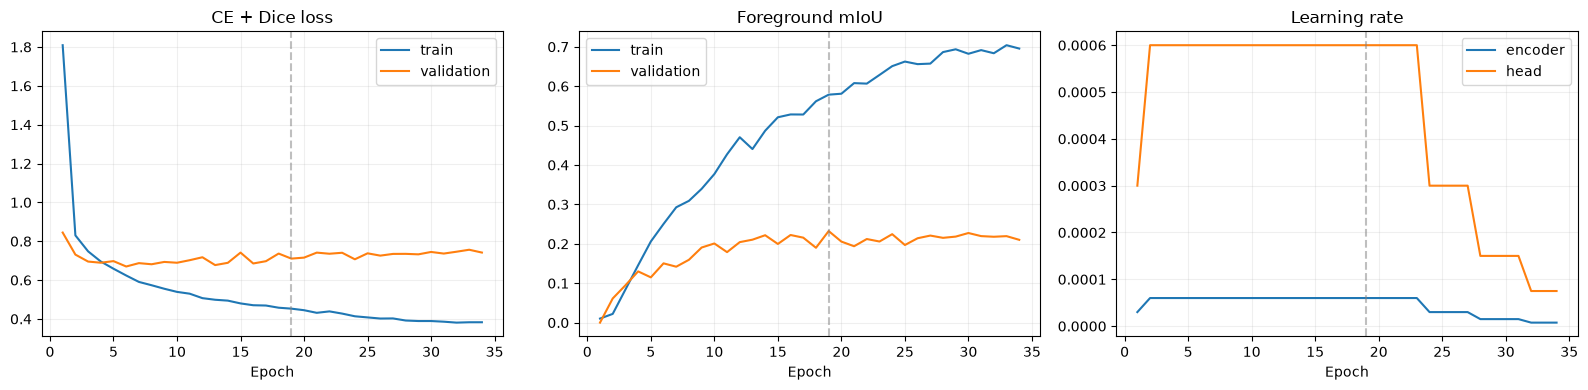

{'miou_foreground': 0.23238557516572422,
 'dice_foreground': 0.36298380330182867,
 'precision_foreground': 0.44042611714997615,
 'recall_foreground': 0.3189544681448199,
 'pixel_accuracy': 0.9318439864968615,
 'valid_pixels': 38247997,
 'macro_class_count': 8,
 'macro_policy': 'background excluded; zero-union classes undefined/excluded; false-positive-only classes included',
 'binary_foreground': {'iou': 0.4353210960778787,
  'precision': 0.7111666202950222,
  'recall': 0.5288166221611116,
  'dice': 0.6065835683282659,
  'true_positive': 1732995,
  'false_positive': 703839,
  'false_negative': 1544124,
  'iou_reason': None,
  'policy': 'Collapse multiclass argmax IDs > 0; ignore 255 truth; no tuned threshold'},
 'loss': 0.7105807982610933,
 'image_count': 132,
 'elapsed_seconds': 8.298687833012082,
 'images_per_second': 15.906129096084994,
 'timing_scope': 'full evaluation including loading, loss and CPU confusion',
 'split': 'val',
 'epoch': 19,
 'run_id': 'damage-segformer-20261001T1

,class_id,class_name,iou,dice,precision,recall,support_pixels,predicted_pixels,iou_reason
0,0,background,0.938437,0.968241,0.956881,0.979874,34970878,35811163,None
1,1,dent,0.362896,0.532536,0.584767,0.488871,872492,729412,None
2,2,cracked,0.197933,0.330458,0.604938,0.227317,150992,56738,None
3,3,scratch,0.259051,0.411502,0.457356,0.374004,294478,240810,None
4,4,flaking,0.029698,0.057684,0.081757,0.044562,30362,16549,None
5,5,broken-part,0.328248,0.494257,0.586982,0.426832,1683207,1223966,None
6,6,paint-chip,0.091272,0.167277,0.189564,0.149678,25655,20257,None
7,7,missing-part,0.271425,0.426962,0.538113,0.353868,207374,136371,None
8,8,corrosion,0.318561,0.483195,0.479931,0.486504,12559,12731,None


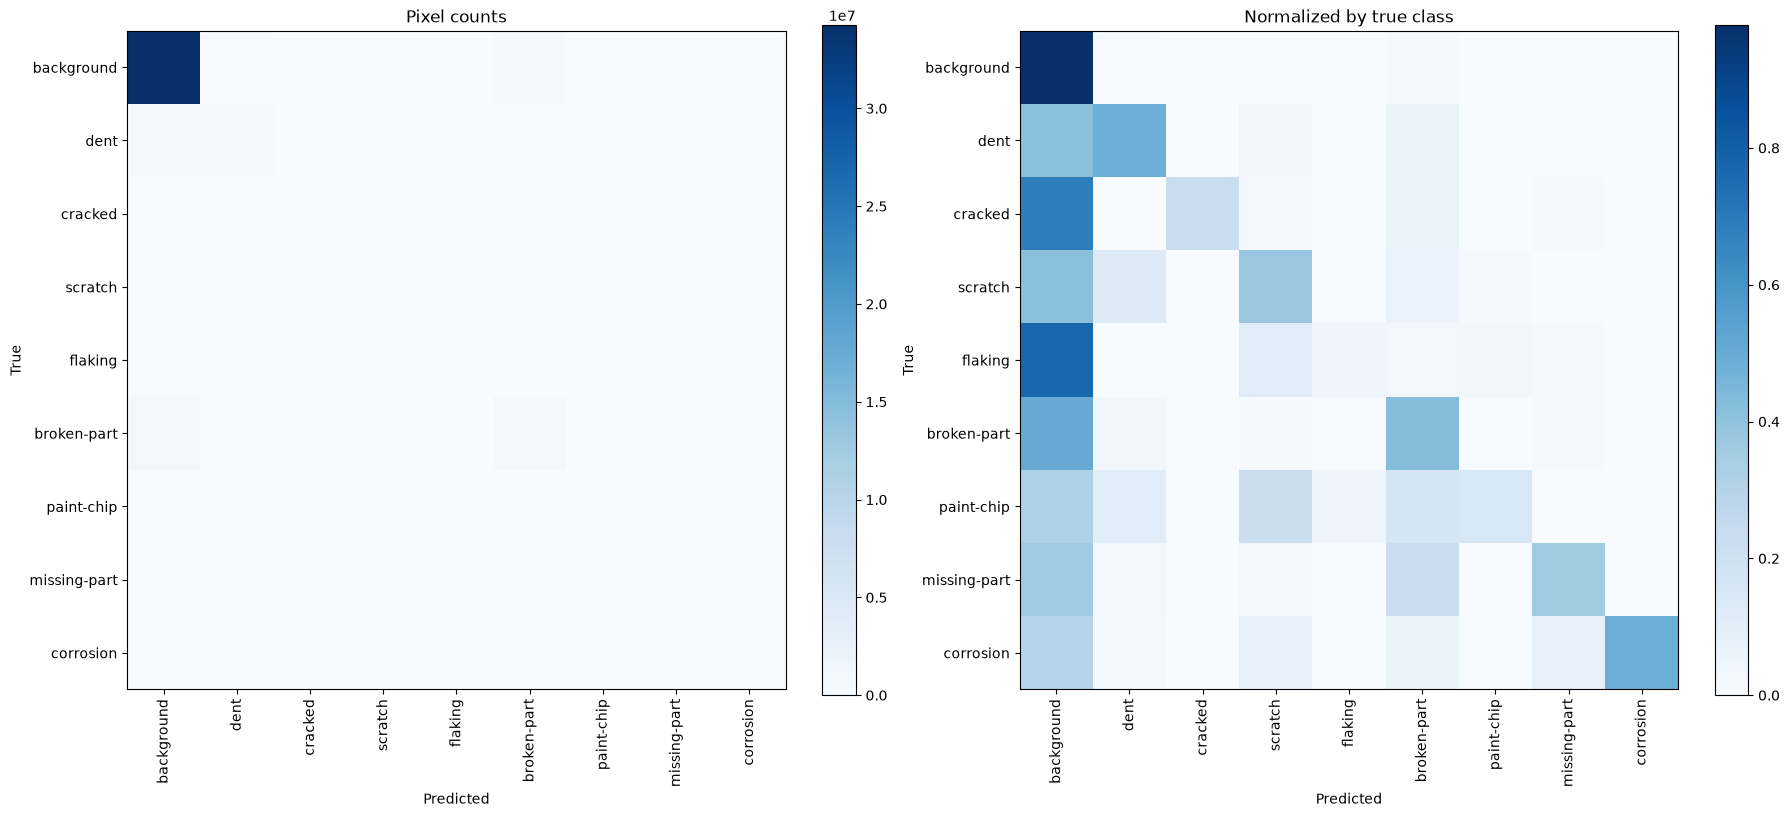

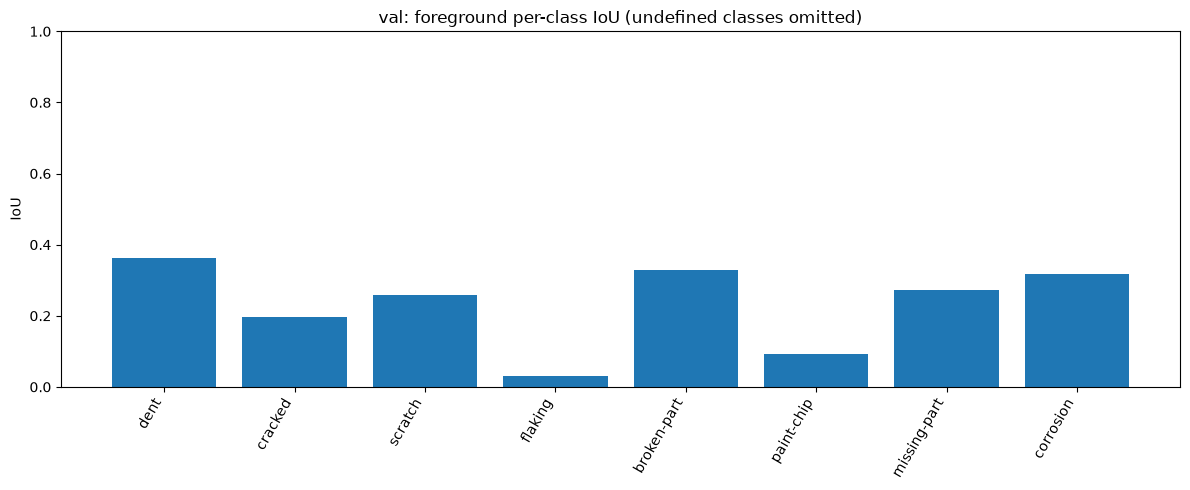

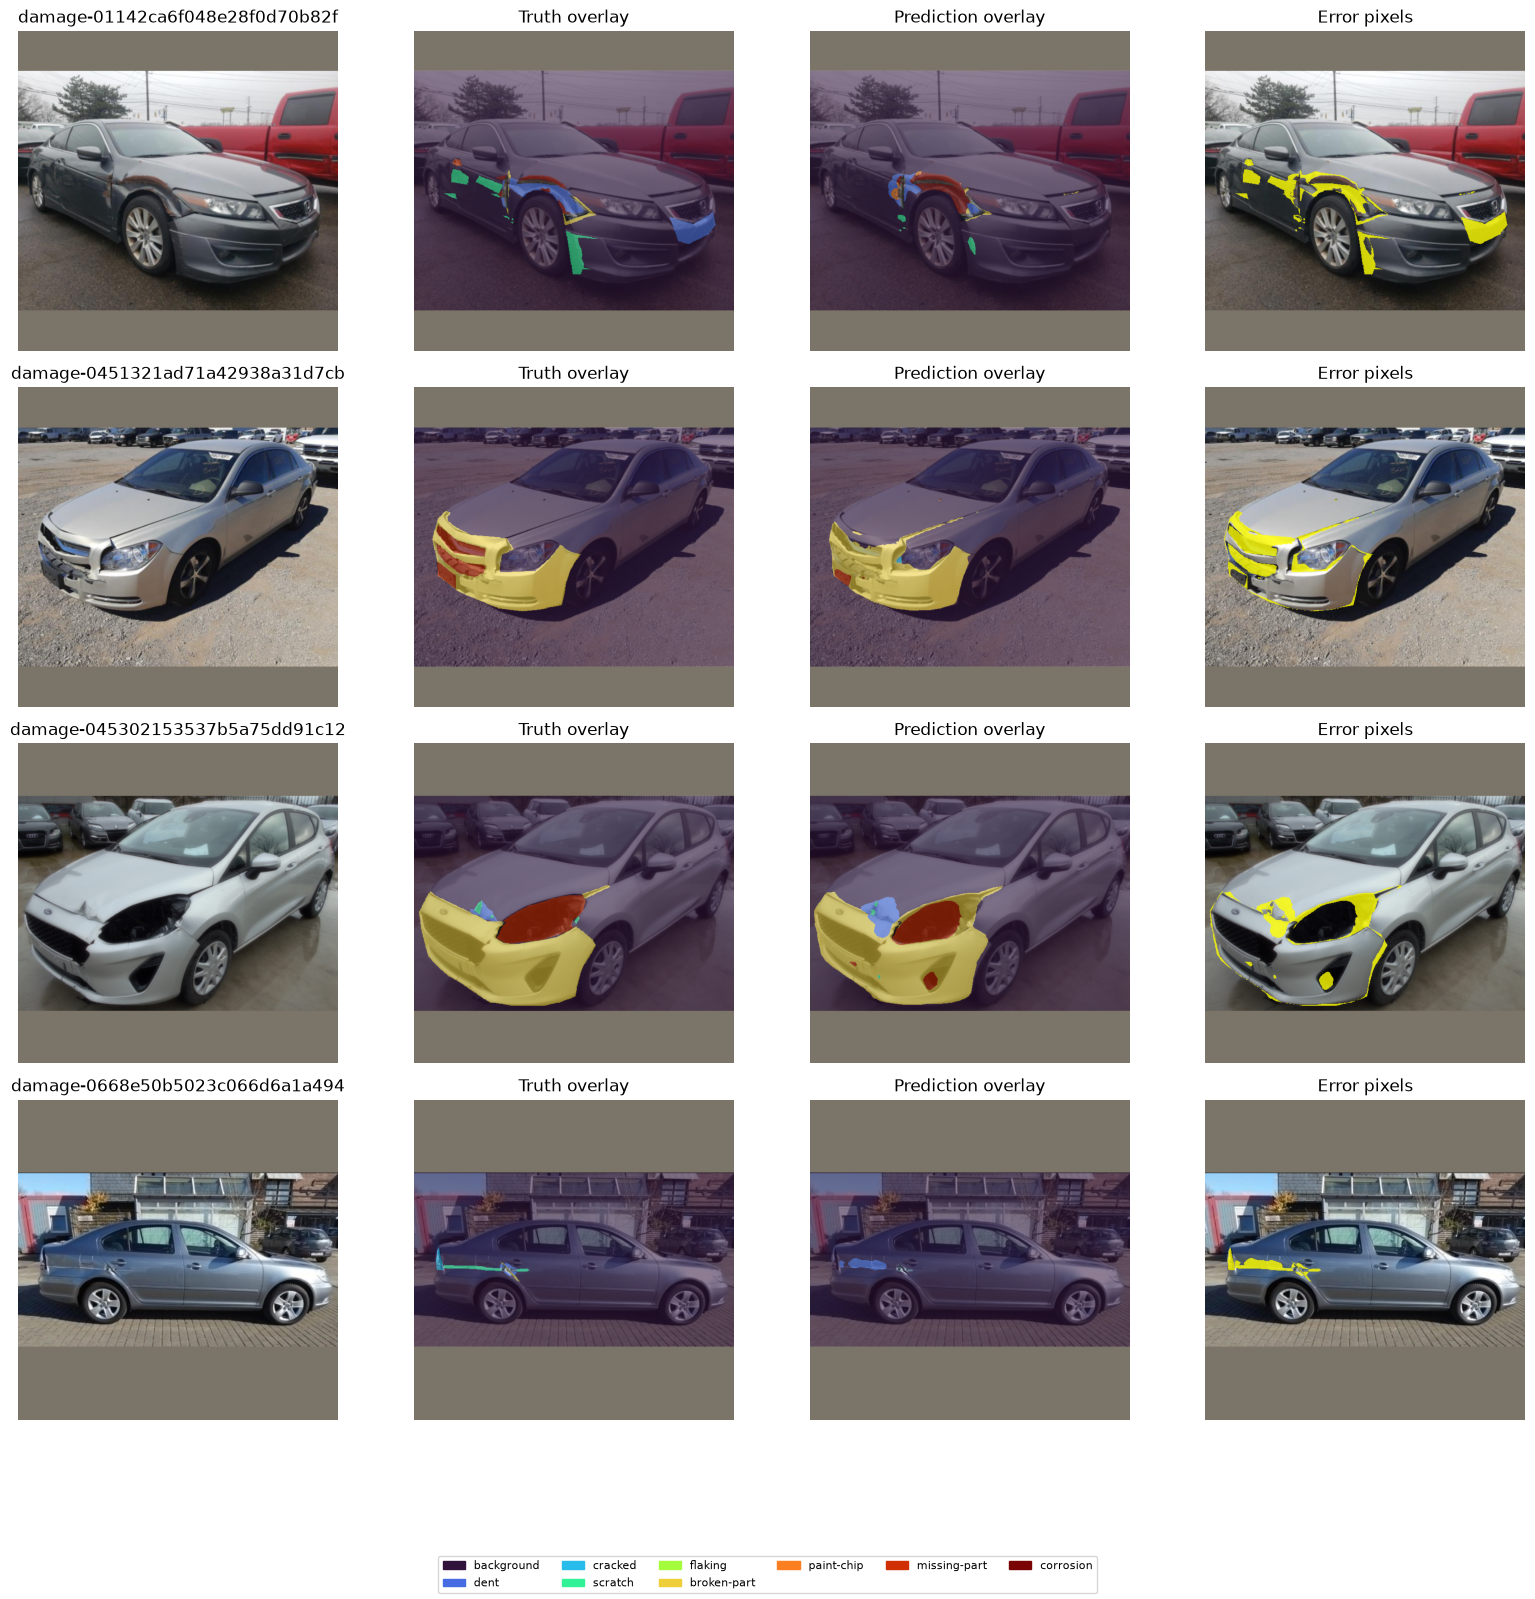

In [11]:
plot_history(RUN_DIR)
plt.show()
validation_report = evaluate_run(RUN_DIR, manifest, split="val", device=DEVICE)
display({k: v for k, v in validation_report.items()
         if k not in {"per_class", "confusion_matrix"}})
display(pd.DataFrame(validation_report["per_class"]))
plot_confusion(RUN_DIR, split="val")
plt.show()
show_predictions(RUN_DIR, manifest, split="val", count=4, device=DEVICE)
plt.show()


## Compare manual runs on a declared common validation resolution

Training at 512 versus 640 changes the evaluation pixel grid if each run is scored at its own size. Set `COMMON_EVAL_SIZE` below before comparing candidates and re-evaluate **every** best checkpoint at that same whole-image resize/padding size. Reports are saved as `val_size640_*` (or the chosen size), preserving each run's original `val_metrics.json`. Common-resolution results may differ from the original 0.2224 reference score. The comparison helper still rejects mismatched task, dataset, taxonomy or split.

This is whole-image resized evaluation, not native-resolution or tiled inference. Freeze the resolution and preprocessing protocol on validation before the final test. Keep compute budget and seed controlled where possible; document intentional differences.


In [12]:
RUNS_TO_COMPARE = [str(RUN_DIR)]
# Add the completed reference or other candidates deliberately:
# RUNS_TO_COMPARE += [str(ROOT / "artifacts/models/damage-hitl/damage-segformer-20261001T003540Z-6203ed59")]
COMMON_EVAL_SIZE = 640  # Same evaluation grid for EVERY compared checkpoint.
for directory in RUNS_TO_COMPARE:
    evaluate_run(directory, manifest, split="val", device=DEVICE, image_size=COMMON_EVAL_SIZE)
comparison = compare_runs(RUNS_TO_COMPARE, evaluation_image_size=COMMON_EVAL_SIZE)
display(comparison)
SAVE_COMPARISON = False
if SAVE_COMPARISON:
    comparison.to_csv(EVALUATION_DIR / "manual_validation_comparison.csv", index=False)


,run_id,architecture,checkpoint,seed,best_epoch,val_miou,val_dice,binary_iou,training_image_size,evaluation_image_size,parameters,device
0,damage-segformer-20261001T151123Z-eacada43,segformer,nvidia/segformer-b2-finetuned-ade-512-512,20260922,19,0.232386,0.362984,0.435321,640,640,27353545,mps


## Reload an existing checkpoint without another training run

After a kernel restart, rerun the imports and preparation/configuration cells, set `RELOAD_RUN_DIR` to a saved run below, then run the validation plotting/evaluation cell. Evaluation rebuilds the architecture from its persisted configuration and loads `best.pt`; it checks task/data compatibility. Move the corresponding prepared dataset and manifest with the run when using another machine, and preserve recorded content identities. This is model reload for inference/evaluation, not optimizer resume.


In [13]:
RELOAD_RUN_DIR = None  # e.g. ROOT / "artifacts/models/damage-hitl/<saved-run-id>"
if RELOAD_RUN_DIR is not None:
    RUN_DIR = Path(RELOAD_RUN_DIR).expanduser().resolve()
    if not (RUN_DIR / "best.pt").is_file():
        raise FileNotFoundError(f"No saved best checkpoint in {RUN_DIR}")
    EVALUATION_DIR = ROOT / "artifacts/evaluation" / RUN_DIR.name
    print("Reload selected:", RUN_DIR)
    reloaded_validation_report = evaluate_run(RUN_DIR, manifest, split="val", device=DEVICE)
    display(reloaded_validation_report)


## Final held-out evaluation — explicit opt-in

Leave `FINAL_EVAL=False` throughout development. Set it to `True` only after selecting and freezing the final run using validation, with no pending split/taxonomy edits. Evaluation exports metrics, the confusion matrix and qualitative results under `artifacts/evaluation/<run_id>/`. Test results must not become a feedback loop for architecture or threshold selection. A later design change requires a new declared evaluation protocol, not repeated claims of untouched test performance.


If selection used common-resolution metrics, use the same `FINAL_EVAL_SIZE` below. Those reports and plots are written separately from the run's original-resolution metrics. Inspect that choice on validation first; changing only the final-test procedure invalidates the comparison.


In [14]:
FINAL_EVAL = False
FINAL_EVAL_SIZE = 640  # Match the frozen common validation protocol.
if FINAL_EVAL:
    final_report = evaluate_run(RUN_DIR, manifest, split="test", device=DEVICE, image_size=FINAL_EVAL_SIZE)
    display({k: v for k, v in final_report.items() if k not in {"per_class", "confusion_matrix"}})
    display(pd.DataFrame(final_report["per_class"]))
    plot_confusion(RUN_DIR, split="test", image_size=FINAL_EVAL_SIZE)
    plt.show()
    show_predictions(RUN_DIR, manifest, split="test", count=4, device=DEVICE, image_size=FINAL_EVAL_SIZE)
    plt.show()
else:
    print("Final test remains unused. Continue model selection with validation only.")


Final test remains unused. Continue model selection with validation only.


## Interpretation, artifacts and next steps

For this HITL M2 experiment, acceptance targets remain to be set before final evaluation. Keep all eight damage classes and their support in reports; do not substitute the CarDD target or class names. Rare Cracked/Corrosion labels warrant explicit error analysis. Damage-to-part assignment needs a separate grouped, reserved evaluation and side remains unresolved.

Model artifacts are isolated under `artifacts/models/damage-hitl/<run_id>/`, and evaluation artifacts under `artifacts/evaluation/<run_id>/`. Keep the dataset/version/config manifest with the checkpoint when copying to another machine. The final evidence package should include best weights, preprocessing and taxonomy, source/split hashes, config and environment, history plots, every class's support/metrics, confusion matrices and sampled prediction overlays. Clear notebook outputs before committing; large generated assets stay ignored.

These notebooks provide trainable semantic segmentation experiments. A completed training cell does not demonstrate calibrated confidence, reliable absence of damage, runtime integration, side identification or required repairs. Production adapters must preserve source coordinates, uncertainty and version references; then be independently integrated and tested.

References: [training specification](../docs/specs/model_training_specification.md), [evaluation plan](../docs/specs/evaluation_plan.md), [M1](../docs/specs/module-01-vehicle-part-segmentation.md), [M2](../docs/specs/module-02-damage-segmentation.md), [dataset acquisition](../docs/dataset-downloads.md), [SegFormer model documentation](https://huggingface.co/docs/transformers/model_doc/segformer), [MiT-B2 model card](https://huggingface.co/nvidia/mit-b2).
